In [21]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import tensorflow as tf
import os
from pathlib import Path
import json

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D
from tensorflow.keras.layers import LSTM, SimpleRNN, GRU
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K

tf.random.set_seed(1234)
np.random.seed(1234)


In [2]:
# -------------------
# Config / constants
# -------------------
INPUT_HORIZON = 12          # timesteps per input sequence
INOUT_DIM = 57              # features (stations)
VALIDATION_SPLIT = 0.05
BATCH_SIZE = 3
EPOCHS = [15, 17, 15, 17, 15, 15]  # per-model epochs
TRAIN_RATE = 1.0            # fraction of first 6000 rows used for training
ACTIVATION = "relu"         # 'relu' as in your script
DATASET_PATH = "./MS_winds.dat"

# Reproducibility
np.random.seed(1234)
tf.random.set_seed(1234)

In [3]:
# -------------------
# Data utilities
# -------------------
def load_raw_winds(path, use_cols=INOUT_DIM):
    """Load CSV and return float ndarray (N, use_cols)."""
    with open(path) as f:
        data = csv.reader(f, delimiter=",")
        rows = [line for line in data]
    winds = np.array(rows, dtype=float)
    winds = winds[:, :use_cols]
    return winds


def normalize_winds_0_1(winds):
    """Min-max normalize to [0,1] across the whole matrix."""
    wind_max = winds.max()
    wind_min = winds.min()
    denom = (wind_max - wind_min)
    norm = (winds - wind_min) / denom
    return norm.astype(np.float32), (wind_min, denom)


def denormalize(vec, mins_denoms):
    """Invert normalization."""
    wind_min, denom = mins_denoms
    return vec * denom + wind_min


def make_rolling_sequences(winds, input_horizon=INPUT_HORIZON):
    """
    Build rolling windows X (N-ih, ih, F) and next-step targets y (N-ih, F).
    """
    result = []
    for i in range(len(winds) - input_horizon):
        result.append(winds[i:i + input_horizon])
    X = np.array(result, dtype=np.float32)                       # (N-ih, ih, F)
    y = winds[input_horizon:len(winds), :].astype(np.float32)    # (N-ih, F)
    return X, y


def split_train_test(X, y, train_end=6000, test_end=6361, train_rate=TRAIN_RATE):
    """
    Match the original indexing:
      - Train on first `train_end` sequences (optionally truncated by train_rate)
      - Test on X[6000:6361], y[6000:6361]
    """
    train_rows = int(train_end * train_rate)
    X_train = X[:train_rows]
    y_train = y[:train_rows]

    X_test = X[train_end:test_end]
    y_test = y[train_end:test_end]
    return X_train, y_train, X_test, y_test

In [4]:
# -------------------
# Model builders
# -------------------
def compile_model(model):
    opt = optimizers.RMSprop(learning_rate=0.001)
    model.compile(loss="mae", optimizer=opt)
    return model


def build_model_lstm_generic(units1, units2=None, output_units=INOUT_DIM,
                             return_sequences_first=False, return_sequences_second=False):
    """
    Generic builder to reproduce the 6 architectures with minimal code.
    - If units2 is None, single LSTM block; else stack two LSTMs.
    """
    m = Sequential()
    # First LSTM (needs input_shape)
    m.add(LSTM(units=units1,
               input_shape=(INPUT_HORIZON, INOUT_DIM),
               return_sequences=return_sequences_first))
    # Optional second LSTM
    if units2 is not None:
        m.add(LSTM(units=units2, return_sequences=return_sequences_second))
    # Output dense to INOUT_DIM
    m.add(Dense(units=output_units))
    m.add(Activation(ACTIVATION))
    return compile_model(m)


def build_model_lstm_1():
    # layers = [in_nodes, 57*2, 57, 32, out_nodes]
    return build_model_lstm_generic(units1=57 * 2, units2=None, output_units=INOUT_DIM,
                                    return_sequences_first=False)


def build_model_lstm_2():
    # layers = [in_dim, 10, 57*2, 32, out_dim] -> one LSTM with 10 units
    return build_model_lstm_generic(units1=10, units2=None, output_units=INOUT_DIM,
                                    return_sequences_first=False)


def build_model_lstm_3():
    # layers = [in_dim, 57, 57*2, 32, out_dim] -> one LSTM with 57 units
    return build_model_lstm_generic(units1=57, units2=None, output_units=INOUT_DIM,
                                    return_sequences_first=False)


def build_model_lstm_4():
    # layers = [in_dim, 57, 57*2, 57, out_dim] -> two LSTMs: 57 (seq) -> 114 (no seq)
    return build_model_lstm_generic(units1=57, units2=57 * 2, output_units=INOUT_DIM,
                                    return_sequences_first=True, return_sequences_second=False)


def build_model_lstm_5():
    # layers = [in_dim, 30, 57*2, 57, out_dim] -> one LSTM with 30 units
    return build_model_lstm_generic(units1=30, units2=None, output_units=INOUT_DIM,
                                    return_sequences_first=False)


def build_model_lstm_6():
    # layers = [in_dim, 114, 114, 57, out_dim] -> two LSTMs: 114 (seq) -> 114 (no seq)
    return build_model_lstm_generic(units1=57 * 2, units2=57 * 2, output_units=INOUT_DIM,
                                    return_sequences_first=True, return_sequences_second=False)

In [5]:
# -------------------
# Training & chaining
# -------------------
def train_model(model, x_train, y_train, epochs, batch_size=BATCH_SIZE, val_split=VALIDATION_SPLIT):
    x_train = x_train.astype(np.float32)
    y_train = y_train.astype(np.float32)
    model.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=epochs,
              validation_split=val_split,
              verbose=1)
    return model


def make_next_training_data(prev_X, prev_y, model):
    """
    Build the training data for the next model using the previous model's predictions,
    following the original logic.
    """
    xTrain = np.ones_like(prev_X, dtype=np.float32)
    yTrain = np.zeros_like(prev_y, dtype=np.float32)

    # NOTE: original code iterates to len(prev_X) - INPUT_HORIZON - 1
    # We keep that behavior to mirror the paper's pipeline.
    limit = len(prev_X) - INPUT_HORIZON - 1
    for ind in range(max(0, limit)):
        tempInput = prev_X[ind]  # shape: (INPUT_HORIZON, INOUT_DIM)
        tempInput = tempInput[np.newaxis, ...]  # (1, ih, F)
        out = model.predict(tempInput, verbose=0)  # (1, F)
        out = out[0]  # (F,)

        # Roll window: drop first row, append prediction
        rolled = np.vstack((prev_X[ind], out))
        rolled = np.delete(rolled, 0, axis=0)  # (ih, F)

        xTrain[ind] = rolled
        yTrain[ind] = prev_y[ind + 1]  # next target

    return xTrain, yTrain

In [6]:
# -------------------
# Testing & metrics
# -------------------
def test_chain(models, x_test):
    """
    Run the 6-model chain autoregressively over the test set, producing predictions.
    """
    predicted = np.zeros((len(x_test), INOUT_DIM), dtype=np.float32)

    for ind in range(len(x_test)):
        model_ind = ind % 6
        if model_ind == 0:
            test_input = x_test[ind][np.newaxis, ...]  # (1, ih, F)
        else:
            # append previous prediction and drop the first timestep
            prev = test_input[0]  # (ih, F)
            prev = np.vstack((prev, predicted[ind - 1]))
            prev = np.delete(prev, 0, axis=0)
            test_input = prev[np.newaxis, ...]

        yhat = models[model_ind].predict(test_input, verbose=0)  # (1, F)
        predicted[ind] = yhat[0]

    return predicted


def error_measures(y_true, y_pred):
    """
    Return MAE, RMSE, NRMSE_maxMin (%), NRMSE_mean (%)
    """
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    nrmse_maxmin = 100.0 * rmse / (y_true.max() - y_true.min())
    nrmse_mean = 100.0 * rmse / (y_true.mean())
    return mae, rmse, nrmse_maxmin, nrmse_mean


def draw_graph_station(y_test_denorm, y_pred_denorm, station, ax=None, visualize=True):
    mae, rmse, nrmse_maxMin, nrmse_mean = error_measures(
        y_test_denorm[:, station], y_pred_denorm[:, station]
    )
    print(f"station {station+1:>2} : "
          f"MAE={mae:7.4f}  RMSE={rmse:7.4f}  "
          f"nrmse_maxMin={nrmse_maxMin:7.4f}%  nrmse_mean={nrmse_mean:7.4f}%")

    if visualize:
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(111)
        ax.plot(y_test_denorm[:, station], label="Real")
        ax.plot(y_pred_denorm[:, station], label="Predicted")
        ax.set_title(f"Station {station+1}")
        ax.legend()

    return mae, rmse, nrmse_maxMin, nrmse_mean


def draw_graph_grid(y_test_denorm, y_pred_denorm, rows=4, cols=4):
    n_plots = rows * cols
    fig, ax_array = plt.subplots(rows, cols, sharex=True, sharey=True, figsize=(12, 8))
    maeRmse = np.zeros((n_plots, 4), dtype=float)

    sta_ind = 0
    for ax in np.ravel(ax_array):
        maeRmse[sta_ind] = draw_graph_station(y_test_denorm, y_pred_denorm, sta_ind, ax=ax, visualize=True)
        sta_ind += 1
        if sta_ind >= y_test_denorm.shape[1]:
            break

    plt.tight_layout()
    plt.show()
    print("Mean errors over plotted stations:", maeRmse.mean(axis=0))
    return maeRmse

In [7]:
# Load & normalize
winds_raw = load_raw_winds(DATASET_PATH, use_cols=INOUT_DIM)
winds_norm, mins_denoms = normalize_winds_0_1(winds_raw)

In [9]:
winds_raw.shape

(8387, 57)

In [12]:
winds_norm.shape, mins_denoms

((8387, 57), (np.float64(0.0), np.float64(22.441)))

In [13]:
# Build base sequences and split
X, y = make_rolling_sequences(winds_norm, INPUT_HORIZON)
X_train, y_train, X_test, y_test = split_train_test(X, y)

In [15]:
X.shape

(8375, 12, 57)

In [17]:
y.shape,X_train.shape

((8375, 57), (6000, 12, 57))

In [18]:
# Train model 1
print("Training LSTM 1 ...")
m1 = build_model_lstm_1()
m1 = train_model(m1, X_train, y_train, EPOCHS[0])

models = [m1]

Training LSTM 1 ...


C:\Users\decis\anaconda3\envs\kaveh\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.0475 - val_loss: 0.0435
Epoch 2/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 0.0345 - val_loss: 0.0379
Epoch 3/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0326 - val_loss: 0.0367
Epoch 4/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 0.0316 - val_loss: 0.0355
Epoch 5/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.0311 - val_loss: 0.0346
Epoch 6/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 0.0307 - val_loss: 0.0345
Epoch 7/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.0304 - val_loss: 0.0341
Epoch 8/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0302 - val_loss: 0.0340
Epoch 9/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - loss: 0.0300 - val_loss: 0.0337
Epoch 10/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0299 - val_loss: 0.0336
Epoch 11/15
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 0.0298 - val_loss: 0.0335
Epoch 12

In [19]:
# Iteratively create training data and train models 2..6
prev_X, prev_y = X_train, y_train
builders = [build_model_lstm_2, build_model_lstm_3, build_model_lstm_4,
            build_model_lstm_5, build_model_lstm_6]

In [20]:
for idx, builder in enumerate(builders, start=2):
    prev_X, prev_y = make_next_training_data(prev_X, prev_y, models[-1])
    print(f"Training LSTM {idx} ...")
    m = builder()
    m = train_model(m, prev_X, prev_y, EPOCHS[idx - 1])
    models.append(m)

Training LSTM 2 ...
Epoch 1/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 0.0734 - val_loss: 0.0787
Epoch 2/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0568 - val_loss: 0.0741
Epoch 3/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0523 - val_loss: 0.0736
Epoch 4/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0499 - val_loss: 0.0723
Epoch 5/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0476 - val_loss: 0.0731
Epoch 6/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0453 - val_loss: 0.0708
Epoch 7/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0418 - val_loss: 0.0700
Epoch 8/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0412 - val_loss: 0.0704
Epoch 9/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0410 - val_loss: 0.0706
Epoch 10/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0409 - val_loss: 0.0708
Epoch 11/17
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0408 - val_l

In [22]:
def save_models(models, out_dir="models", mins_denoms=None):
    """
    Save a list of Keras models: models[0]..models[5] -> out_dir/lstm1.keras ... lstm6.keras
    Optionally save normalization params (mins_denoms) to out_dir/scaler.json.
    """
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    for i, m in enumerate(models, start=1):
        path = out / f"lstm{i}.keras"      # TF/Keras native format
        m.save(path)                       # includes architecture+weights+optimizer state
        print(f"Saved: {path}")

    if mins_denoms is not None:
        (out / "scaler.json").write_text(json.dumps({"wind_min": float(mins_denoms[0]),
                                                     "denom": float(mins_denoms[1])}))
        print(f"Saved: {out/'scaler.json'}")

def load_models(model_dir="models"):
    """
    Load six models from model_dir/lstm1.keras ... lstm6.keras (returns list of 6 models).
    If scaler.json exists, also returns mins_denoms = (wind_min, denom); else None.
    """
    model_dir = Path(model_dir)
    models = []
    for i in range(1, 7):
        path = model_dir / f"lstm{i}.keras"
        m = tf.keras.models.load_model(path)
        models.append(m)
        print(f"Loaded: {path}")

    scaler_path = model_dir / "scaler.json"
    mins_denoms = None
    if scaler_path.exists():
        s = json.loads(scaler_path.read_text())
        mins_denoms = (s["wind_min"], s["denom"])
        print(f"Loaded: {scaler_path}")

    return models, mins_denoms



In [23]:
# after you build 'models' list and have mins_denoms
save_models(models, out_dir="models", mins_denoms=mins_denoms)


Saved: models\lstm1.keras
Saved: models\lstm2.keras
Saved: models\lstm3.keras
Saved: models\lstm4.keras
Saved: models\lstm5.keras
Saved: models\lstm6.keras
Saved: models\scaler.json


In [24]:
# Load models (and scaler if saved)
models, saved_scaler = load_models("models")
mins_denoms_to_use = saved_scaler if saved_scaler is not None else mins_denoms_from_data

Loaded: models\lstm1.keras
Loaded: models\lstm2.keras
Loaded: models\lstm3.keras
Loaded: models\lstm4.keras
Loaded: models\lstm5.keras
Loaded: models\lstm6.keras
Loaded: models\scaler.json


...... TESTING ...
station  1 : MAE= 1.4936  RMSE= 1.9988  nrmse_maxMin=11.8914%  nrmse_mean=33.2836%
station  2 : MAE= 0.7174  RMSE= 0.9708  nrmse_maxMin=13.5730%  nrmse_mean=37.1013%
station  3 : MAE= 1.2811  RMSE= 1.8002  nrmse_maxMin=15.3704%  nrmse_mean=51.2650%
station  4 : MAE= 1.2280  RMSE= 1.6409  nrmse_maxMin=18.9195%  nrmse_mean=45.5624%
station  5 : MAE= 0.9143  RMSE= 1.3146  nrmse_maxMin=14.3449%  nrmse_mean=38.0095%
station  6 : MAE= 1.0494  RMSE= 1.4389  nrmse_maxMin=14.1174%  nrmse_mean=40.0306%
station  7 : MAE= 0.9985  RMSE= 1.3353  nrmse_maxMin=13.7641%  nrmse_mean=36.7673%
station  8 : MAE= 1.2443  RMSE= 1.6100  nrmse_maxMin=13.7467%  nrmse_mean=40.8686%
station  9 : MAE= 0.8952  RMSE= 1.2721  nrmse_maxMin=10.8611%  nrmse_mean=36.8052%
station 10 : MAE= 0.7754  RMSE= 1.0853  nrmse_maxMin=19.2683%  nrmse_mean=40.1521%
station 11 : MAE= 1.1874  RMSE= 1.6366  nrmse_maxMin=11.4760%  nrmse_mean=31.6834%
station 12 : MAE= 1.0389  RMSE= 1.5303  nrmse_maxMin=13.6373%  nrmse

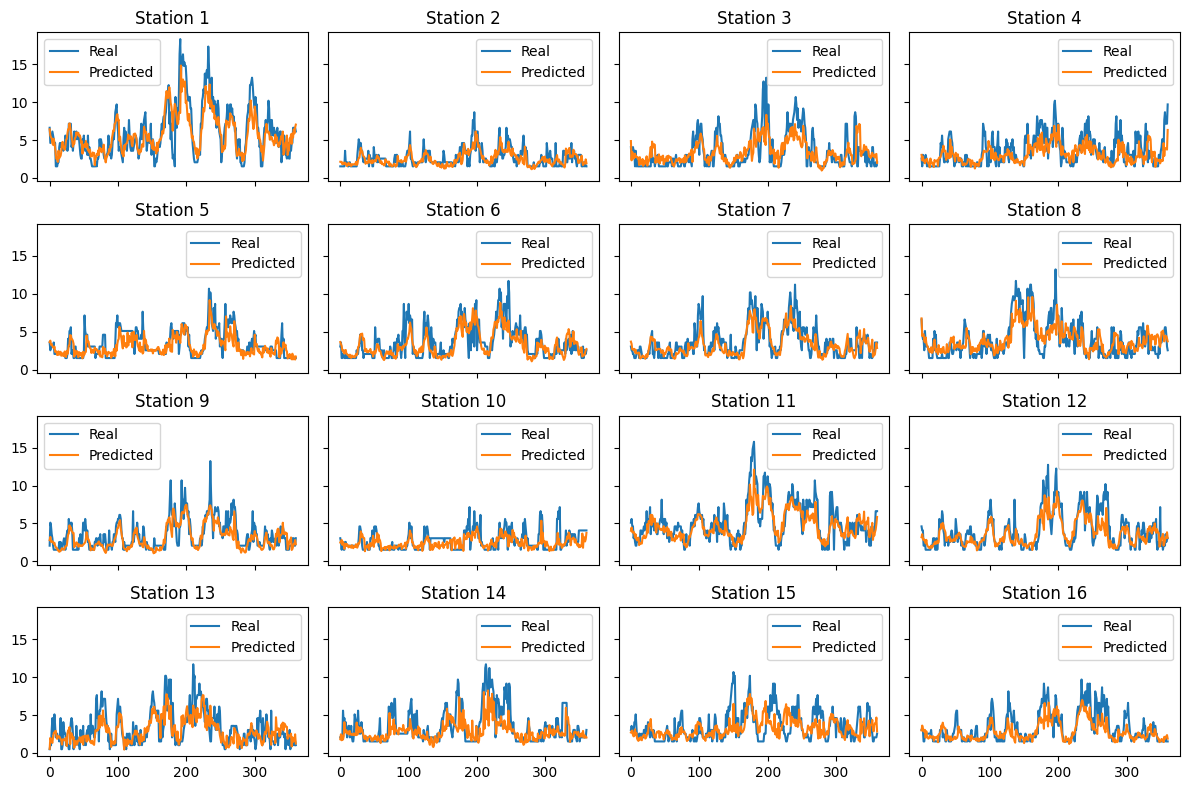

Mean errors over plotted stations: [ 1.11183338  1.53569762 15.1896221  42.03022146]


array([[ 1.49360776,  1.9988296 , 11.89135456, 33.2836113 ],
       [ 0.71743476,  0.97083771, 13.5730257 , 37.10126495],
       [ 1.28105891,  1.8001945 , 15.37038326, 51.26504135],
       [ 1.2279973 ,  1.64090931, 18.91952515, 45.562397  ],
       [ 0.91431248,  1.31457734, 14.34486103, 38.00946426],
       [ 1.04941952,  1.43885732, 14.11737728, 40.0306015 ],
       [ 0.99847782,  1.33526802, 13.76408768, 36.76729584],
       [ 1.24425983,  1.61002839, 13.74671078, 40.86858368],
       [ 0.89522511,  1.27206075, 10.86108303, 36.80521774],
       [ 0.77541834,  1.08532631, 19.26831436, 40.15205765],
       [ 1.18739486,  1.636603  , 11.47599411, 31.68343353],
       [ 1.03886008,  1.53025734, 13.63732147, 37.94787979],
       [ 1.32121134,  1.72467327, 15.37106323, 53.23697281],
       [ 1.30248046,  1.89440811, 18.58702278, 54.09486008],
       [ 1.34461308,  1.87281871, 20.43647385, 52.2839241 ],
       [ 0.99756247,  1.44551229, 17.66935539, 43.39093781]])

In [25]:
# Test chain
print("...... TESTING ...")
y_pred = test_chain(models, X_test)

# Denormalize for metrics/plots
y_test_denorm = denormalize(y_test, mins_denoms_to_use)
y_pred_denorm = denormalize(y_pred, mins_denoms_to_use)

# Plot a grid of stations (first 16)
draw_graph_grid(y_test_denorm, y_pred_denorm, rows=4, cols=4)